In [1]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.2  # Node power consumption in W
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/Almagro_2005_2023.csv"

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from visualization import (
    get_config_trace,
    plot_soc,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc,
    plot_full_soc_analysis,
    plot_pareto_front,
)


## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability
6. Compute Optimal solutions (Pareto Front)
7. Compute scores of the solutions in Pareto front

In [3]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [4]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.0001,0.011,0.70
1,0.0001,0.011,0.75
2,0.0001,0.011,0.80
3,0.0001,0.011,0.85
4,0.0001,0.011,0.87
...,...,...,...
3339,10.0000,10.200,0.85
3340,10.0000,10.200,0.87
3341,10.0000,10.200,0.90
3342,10.0000,10.200,0.95


In [5]:
## Explore Results

In [6]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.031000,1.6,0.98,8760,0,3170,0.837673,0.168340,253.008908,2176.910290,8760,0,4.8,1.258036,0.0,0.361872,-1923.901382,2.103809
1,0.038500,1.4,0.95,8760,0,3295,0.814708,0.195536,259.780371,2583.187422,8760,0,2.0,1.478678,0.0,0.376142,-2323.407051,2.093612
2,0.040000,1.2,0.98,8760,0,3379,0.794504,0.219992,251.444060,2871.590443,8760,0,1.2,1.638651,0.0,0.385731,-2620.146382,2.093551
3,0.040000,1.6,0.90,8760,0,3218,0.825583,0.181753,274.313731,2405.630998,8760,0,4.8,1.378065,0.0,0.367352,-2131.317267,2.091744
4,0.030414,1.8,0.98,8760,0,3152,0.855032,0.149992,253.142654,2131.709489,8760,0,3.6,1.233253,0.0,0.359817,-1878.566835,2.088426
5,0.040000,1.4,0.95,8760,0,3327,0.815964,0.195119,259.559006,2692.022970,8760,0,2.0,1.538289,0.0,0.379795,-2432.463964,2.086018
6,0.030414,2.0,0.95,8760,0,3083,0.862899,0.140549,261.364668,1996.844130,8760,0,2.0,1.157332,0.0,0.351941,-1735.479462,2.084847
7,0.031000,1.8,0.98,8760,0,3170,0.855710,0.149636,253.008908,2176.910290,8760,0,3.6,1.258036,0.0,0.361872,-1923.901382,2.084180
8,0.038500,1.8,0.90,8760,0,3182,0.843599,0.162202,274.565221,2307.974741,8760,0,3.6,1.324563,0.0,0.363242,-2033.409520,2.080639
9,0.031000,2.0,0.95,8760,0,3101,0.863601,0.140143,261.223978,2039.313626,8760,0,2.0,1.180620,0.0,0.353995,-1778.089648,2.080602


## Best combinations

In [7]:
print(summary["score"].max())
best_configs = summary[summary["score"] == summary["score"].max()]

print(len(best_configs))

for config_idx, config_row in best_configs.iterrows():
    print()
    print(config_row[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

2.103809297314003
1

panel_area_m2    0.031000
C_batt_Ah        1.600000
eta_PMU          0.980000
score            2.103809
Name: 0, dtype: float64


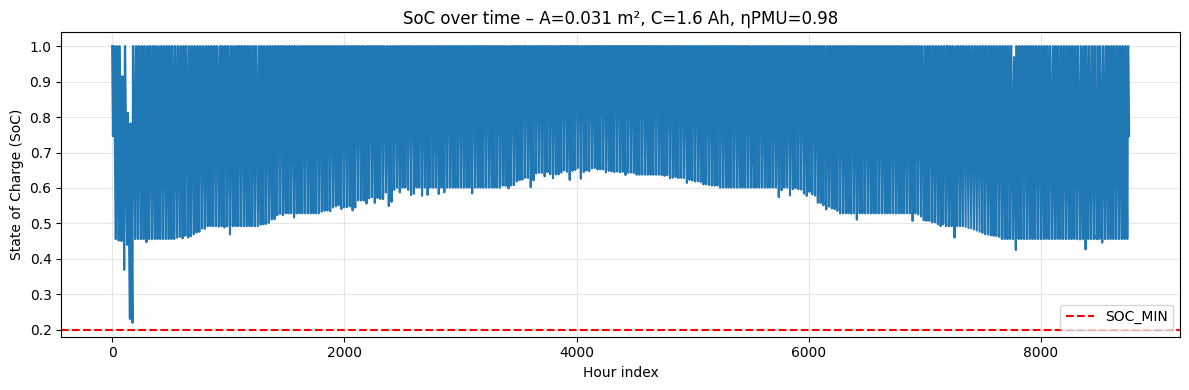

In [8]:
for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [9]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [10]:
summary_plot = summary[summary["score"] > 0].copy()

fig = px.histogram(
    summary_plot,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution (score > 0)",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

In [11]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Summary statistics

In [12]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")
print(f"Viable configurations (score > 0): {len(summary[summary['score'] > 0])}")
print(f"Configurations with failures: {len(summary[summary['failure_hours'] > 0])}")
print("Configuration with I_req_max > I_batt_max):",
      len(summary[summary["I_req_max_A"] > summary["I_batt_max_A"]]))



=== Simulation Summary ===
Total configurations evaluated: 3344
Best score achieved: 2.1038
Configurations with best score: 1
Viable configurations (score > 0): 207
Configurations with failures: 3137
Configuration with I_req_max > I_batt_max): 891


## Invalidad configs due to < SoC_min

In [13]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
2352,0.000400,0.011,0.80,8760,1,0.011,0.067568
2351,0.000400,0.011,0.75,8760,1,0.011,0.072072
2350,0.000400,0.011,0.70,8760,1,0.011,0.077220
2344,0.000400,0.011,0.98,8760,1,0.011,0.055157
2356,0.000400,0.011,0.95,8760,1,0.011,0.056899
...,...,...,...,...,...,...,...
962,0.040000,2.000,0.85,1,8584,2.000,1.226647
1232,0.056797,1.600,0.80,1,8607,4.800,1.557409
409,0.030414,1.600,0.98,1,8584,4.800,1.233253
1097,0.040000,1.800,0.87,1,8584,3.600,1.286157


## Invalid configs due I_req > I_batt_max

In [14]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
166,10.000000,1.600,0.98,422.853041,4.800,0,8760
179,10.000000,2.000,0.98,422.853041,2.000,0,8760
149,10.000000,1.100,0.98,422.853041,2.000,0,8760
1194,10.000000,0.750,0.98,422.853041,1.500,844,1895
1202,10.000000,0.880,0.98,422.853041,1.760,364,4487
...,...,...,...,...,...,...,...
2235,0.000100,0.011,0.98,0.055157,0.011,8760,1
1858,0.000625,0.011,0.98,0.055157,0.011,8760,1
2087,0.001000,0.011,0.98,0.055157,0.011,8760,1
3040,0.002500,0.011,0.98,0.055157,0.011,6858,10


In [15]:
summary["autonomy_hours"].describe()


count    3344.00000
mean     1521.29067
std      2868.01258
min         1.00000
25%        15.00000
50%        19.00000
75%      1391.00000
max      8760.00000
Name: autonomy_hours, dtype: float64

In [16]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
1853,0.000625,0.011,0.80,8760,8759,1,0.200091,0.008547,541.552404,-0.0,1,8760,0.011,0.067568,0.999886,0.000114,541.552404,0.0
1852,0.000625,0.011,0.75,8760,8759,1,0.200091,0.008547,581.011864,-0.0,1,8760,0.011,0.072072,0.999886,0.000114,581.011864,0.0
2350,0.000400,0.011,0.70,8760,8759,1,0.200091,0.008547,644.230604,-0.0,1,8760,0.011,0.077220,0.999886,0.000114,644.230604,0.0
1858,0.000625,0.011,0.98,8760,8759,1,0.200091,0.008547,432.837567,-0.0,1,8760,0.011,0.055157,0.999886,0.000114,432.837567,0.0
1857,0.000625,0.011,0.95,8760,8759,1,0.200091,0.008547,448.095790,-0.0,1,8760,0.011,0.056899,0.999886,0.000114,448.095790,0.0


In [17]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
2,0.040000,1.2,0.98,8760,0,3379,0.794504,0.219992,251.444060,2871.590443,8760,0,1.2,1.638651,0.0,0.385731,-2620.146382,2.093551
1,0.038500,1.4,0.95,8760,0,3295,0.814708,0.195536,259.780371,2583.187422,8760,0,2.0,1.478678,0.0,0.376142,-2323.407051,2.093612
0,0.031000,1.6,0.98,8760,0,3170,0.837673,0.168340,253.008908,2176.910290,8760,0,4.8,1.258036,0.0,0.361872,-1923.901382,2.103809
32,0.040000,2.3,0.85,8760,0,3094,0.867306,0.135841,290.850155,2135.350658,8760,0,46.0,1.226647,0.0,0.353196,-1844.500503,2.051886
71,0.056797,1.8,0.90,8760,0,3487,0.854036,0.158511,272.319309,3499.851392,8760,0,3.6,1.977177,0.0,0.398059,-3227.532084,2.007862


In [18]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_bad = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

# 4) Failure case (for comparison)
cfg_fail = summary[summary["score"] == 0].sort_values("score").iloc[0]


print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== BAD NON-ZERO SCORE CONFIGURATION ===")
print(cfg_bad[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== FAILURE CASE CONFIGURATION ===")
print(cfg_fail[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.031000
C_batt_Ah        1.600000
eta_PMU          0.980000
score            2.103809
Name: 0, dtype: float64

=== BAD NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    10.000000
C_batt_Ah        10.200000
eta_PMU           0.800000
score             0.000465
Name: 202, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    10.000000
C_batt_Ah         2.500000
eta_PMU           0.870000
score             0.756182
Name: 193, dtype: float64

=== FAILURE CASE CONFIGURATION ===
panel_area_m2    0.025
C_batt_Ah        1.100
eta_PMU          0.800
score            0.000
Name: 207, dtype: float64


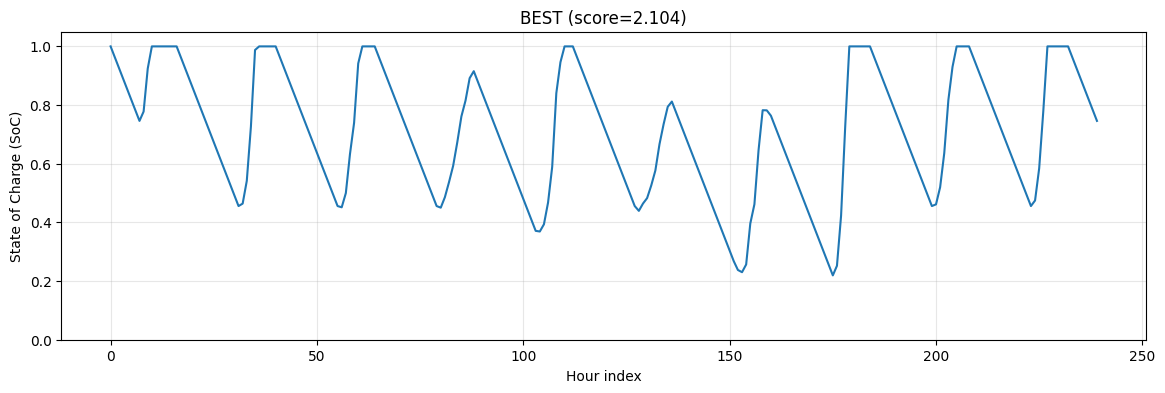

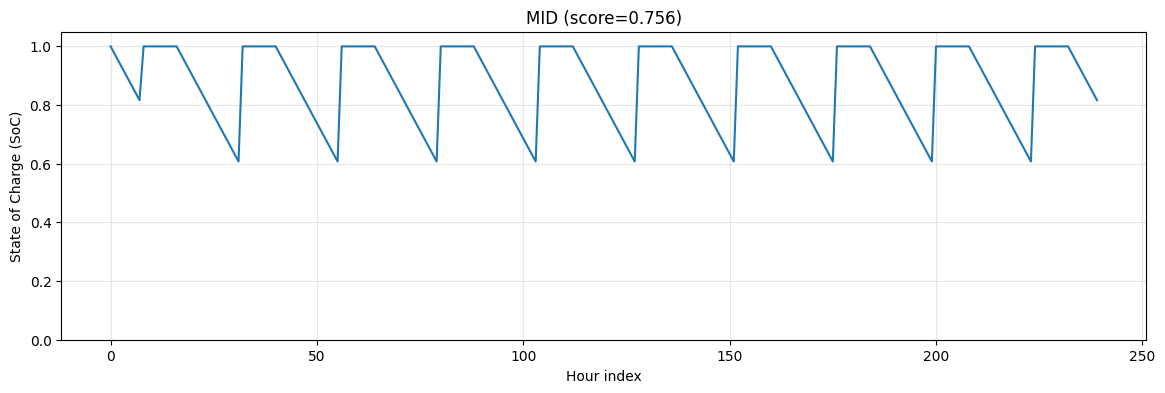

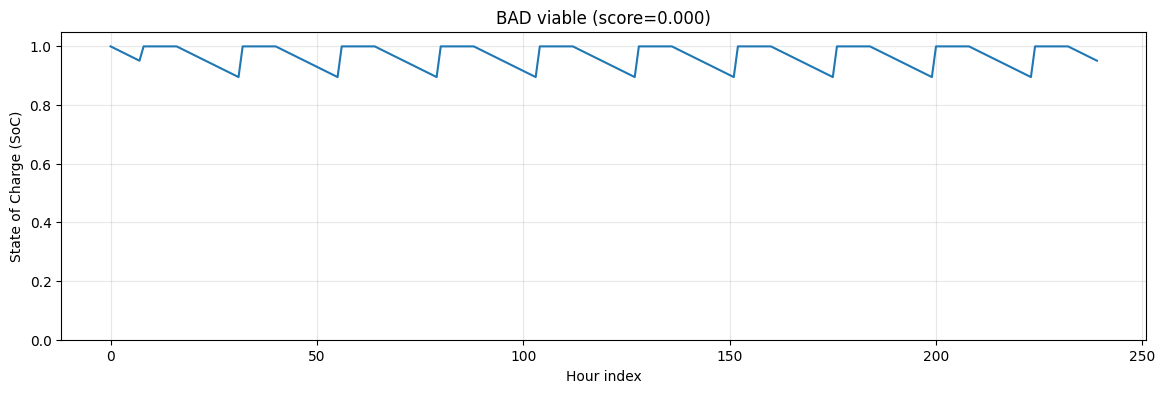

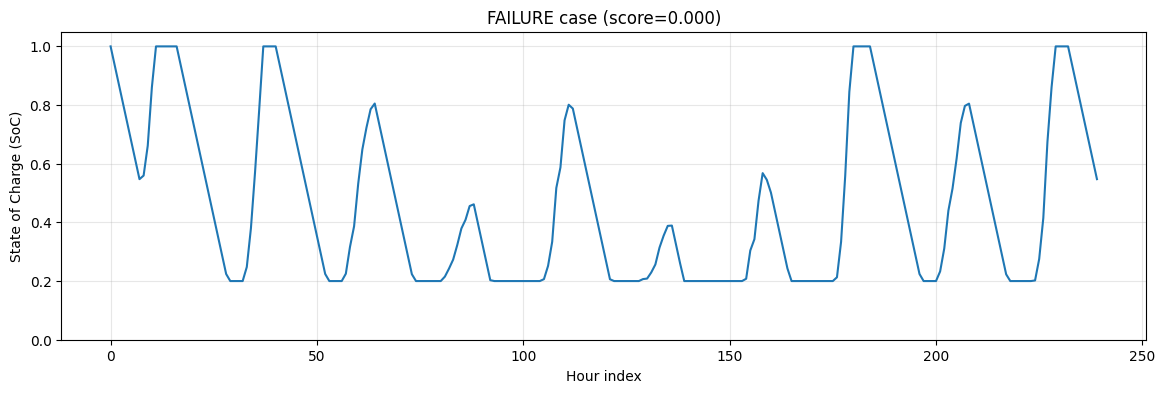

In [19]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# BAD NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    title=f"BAD viable (score={cfg_bad['score']:.3f})"
)

# FAILURE CASE
plot_soc(
    df_soc,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    title=f"FAILURE case (score={cfg_fail['score']:.3f})"
)

In [20]:
from visualization import (
    get_config_trace,
    plot_soc_gh,
    plot_soc_ibatt,
    plot_daily,
    plot_seasonal_soc
)


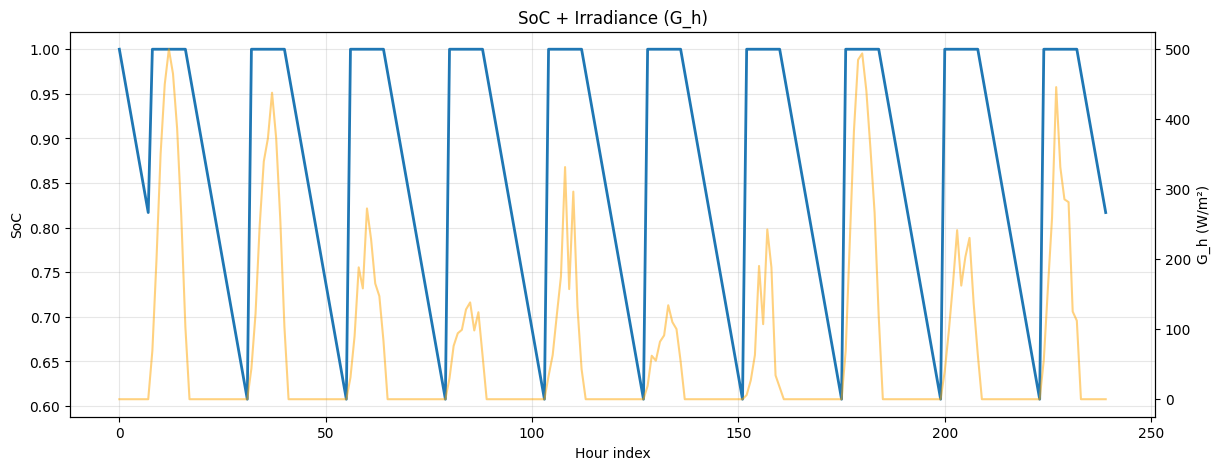

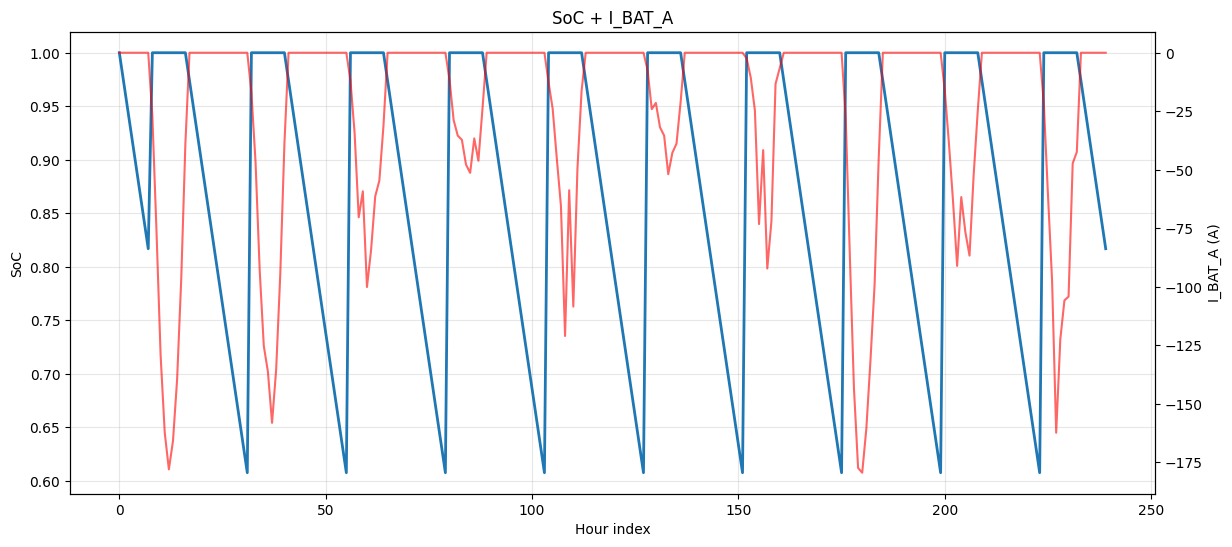

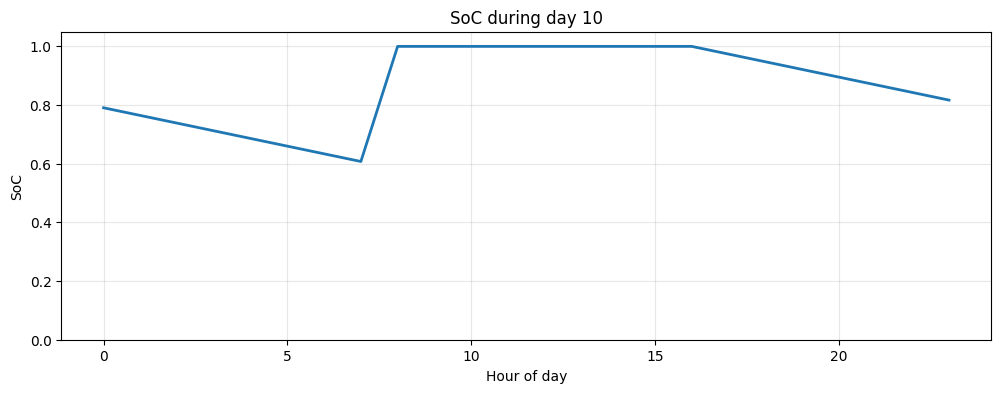

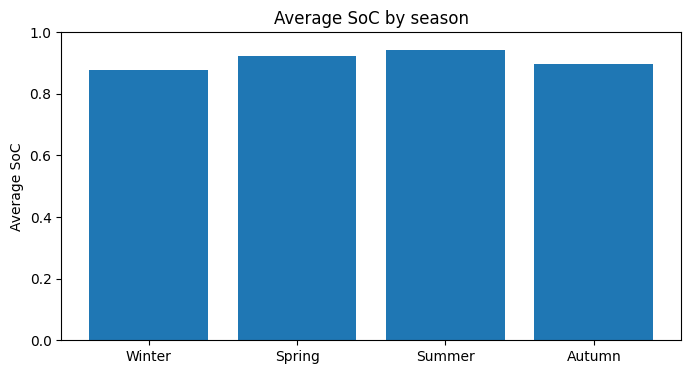

In [21]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [22]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]
title_best = f"BEST - Panel: {cfg_best['panel_area_m2']} m², Batería: {cfg_best['C_batt_Ah']} Ah, PMU: {cfg_best['eta_PMU']}, Score: {cfg_best['score']:.3f}"

# 2) BAD non-zero score
cfg_bad = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]
title_bad = f"BAD - Panel: {cfg_bad['panel_area_m2']} m², Batería: {cfg_bad['C_batt_Ah']} Ah, PMU: {cfg_bad['eta_PMU']}, Score: {cfg_bad['score']:.3f}"

# 3) MID score (between BAD and BEST)
configs_between = summary_sorted[
    (summary_sorted["score"] > cfg_bad["score"]) &
    (summary_sorted["score"] < cfg_best["score"])
].sort_values("score")
cfg_mid = configs_between.iloc[len(configs_between) // 2]
title_mid = f"MID - Panel: {cfg_mid['panel_area_m2']} m², Batería: {cfg_mid['C_batt_Ah']} Ah, PMU: {cfg_mid['eta_PMU']}, Score: {cfg_mid['score']:.3f}"

# 4) Failure case (for comparison)
cfg_fail = summary_sorted[summary_sorted["score"] == 0].sort_values("score").iloc[0]
title_fail = f"FAIL - Panel: {cfg_fail['panel_area_m2']} m², Batería: {cfg_fail['C_batt_Ah']} Ah, PMU: {cfg_fail['eta_PMU']}, Score: {cfg_fail['score']:.3f}"

print("\nBEST:", cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:", cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nBAD:", cfg_bad[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nFAIL:", cfg_fail[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.031000
C_batt_Ah        1.600000
eta_PMU          0.980000
score            2.103809
Name: 0, dtype: float64

MID: panel_area_m2     0.025000
C_batt_Ah        10.200000
eta_PMU           0.750000
score             1.514142
Name: 100, dtype: float64

BAD: panel_area_m2    10.000000
C_batt_Ah        10.200000
eta_PMU           0.800000
score             0.000465
Name: 202, dtype: float64

FAIL: panel_area_m2    0.025
C_batt_Ah        1.100
eta_PMU          0.800
score            0.000
Name: 207, dtype: float64


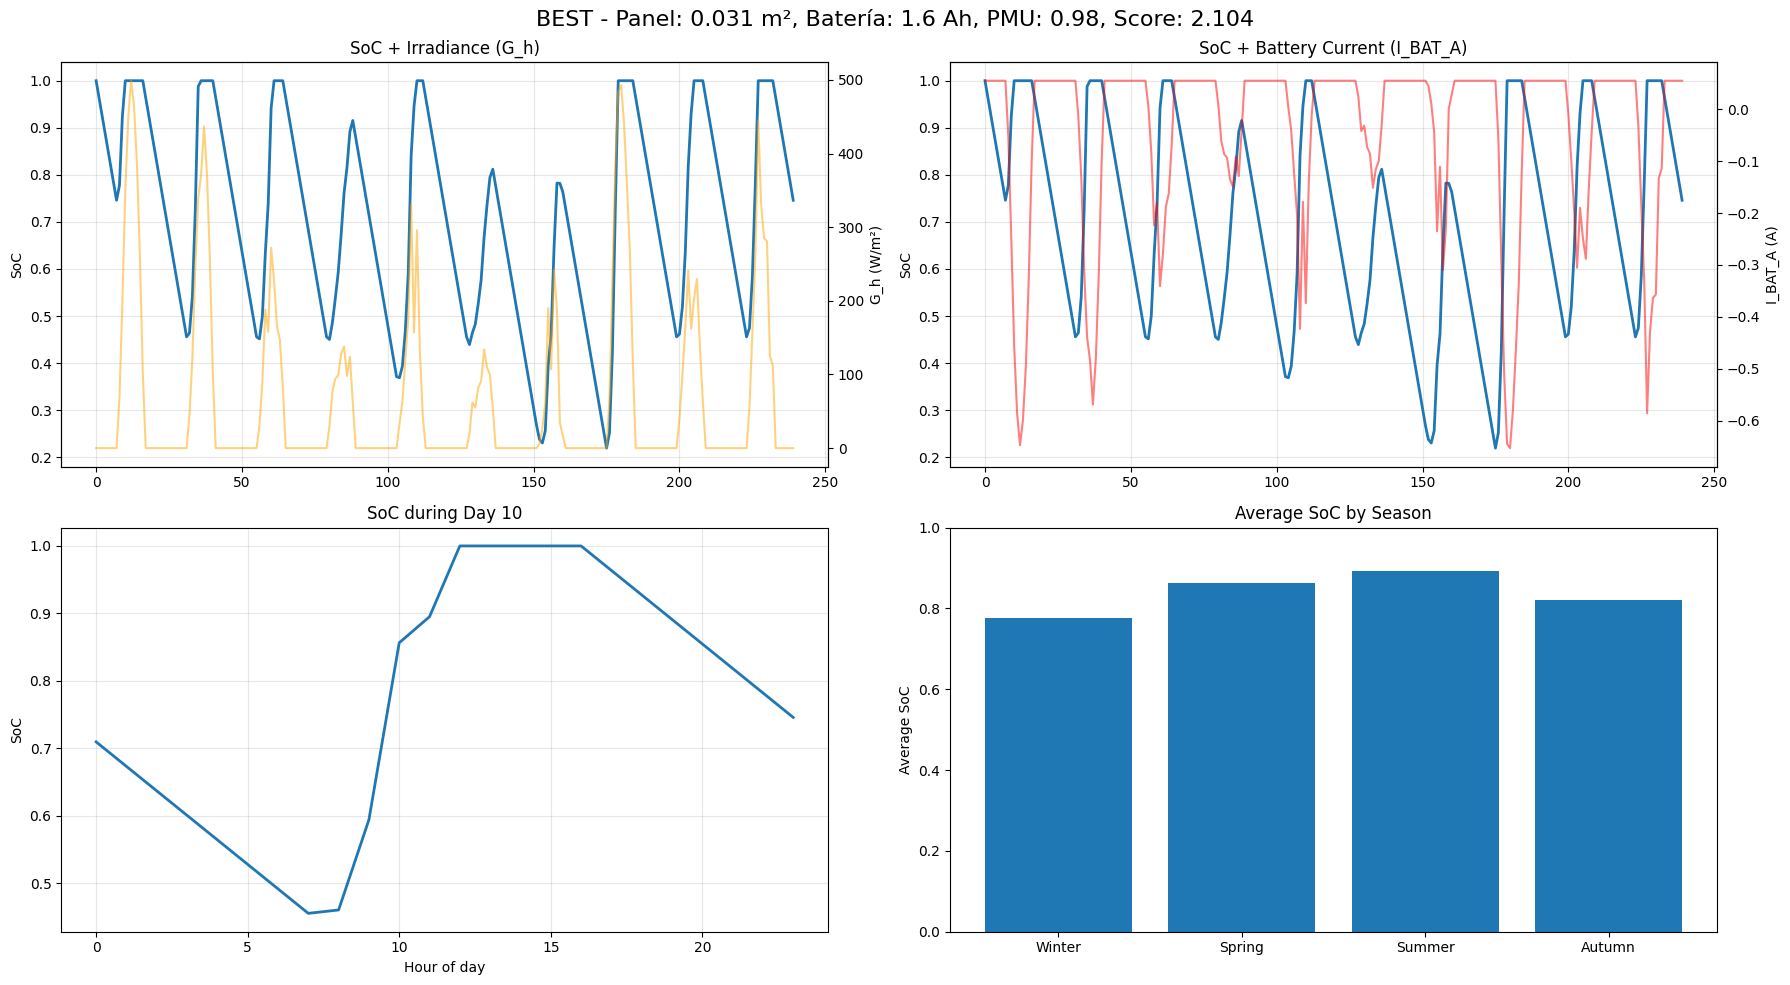

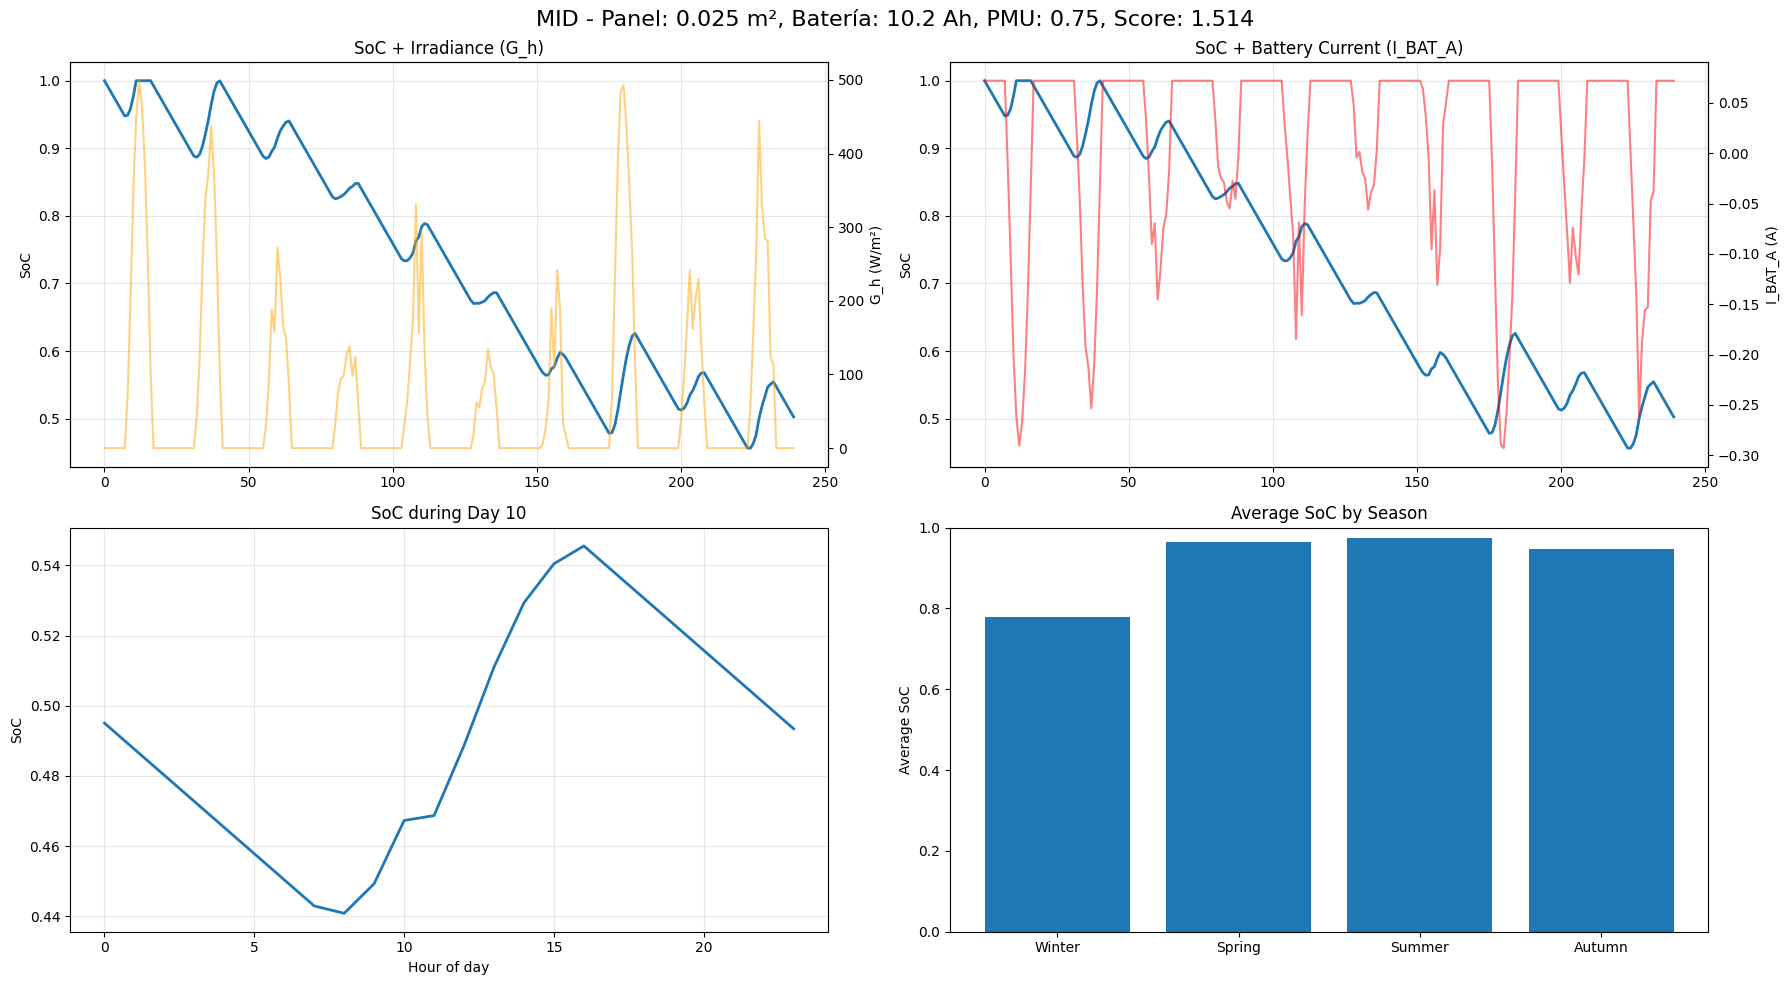

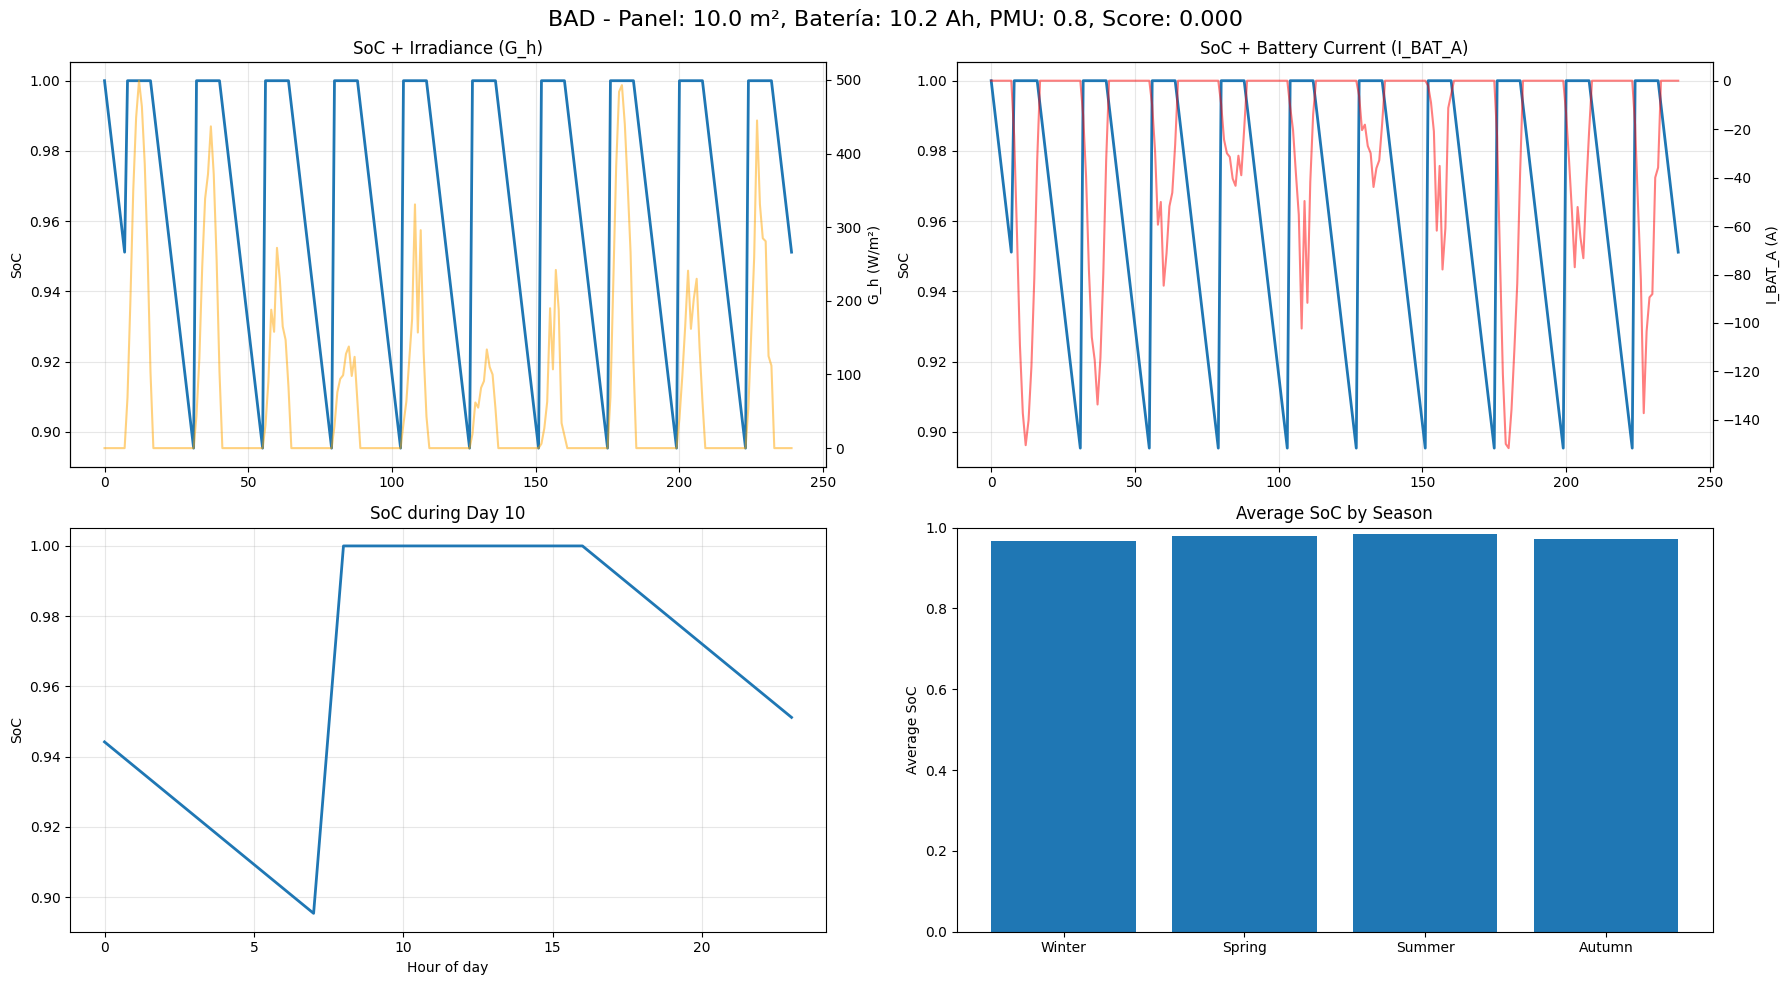

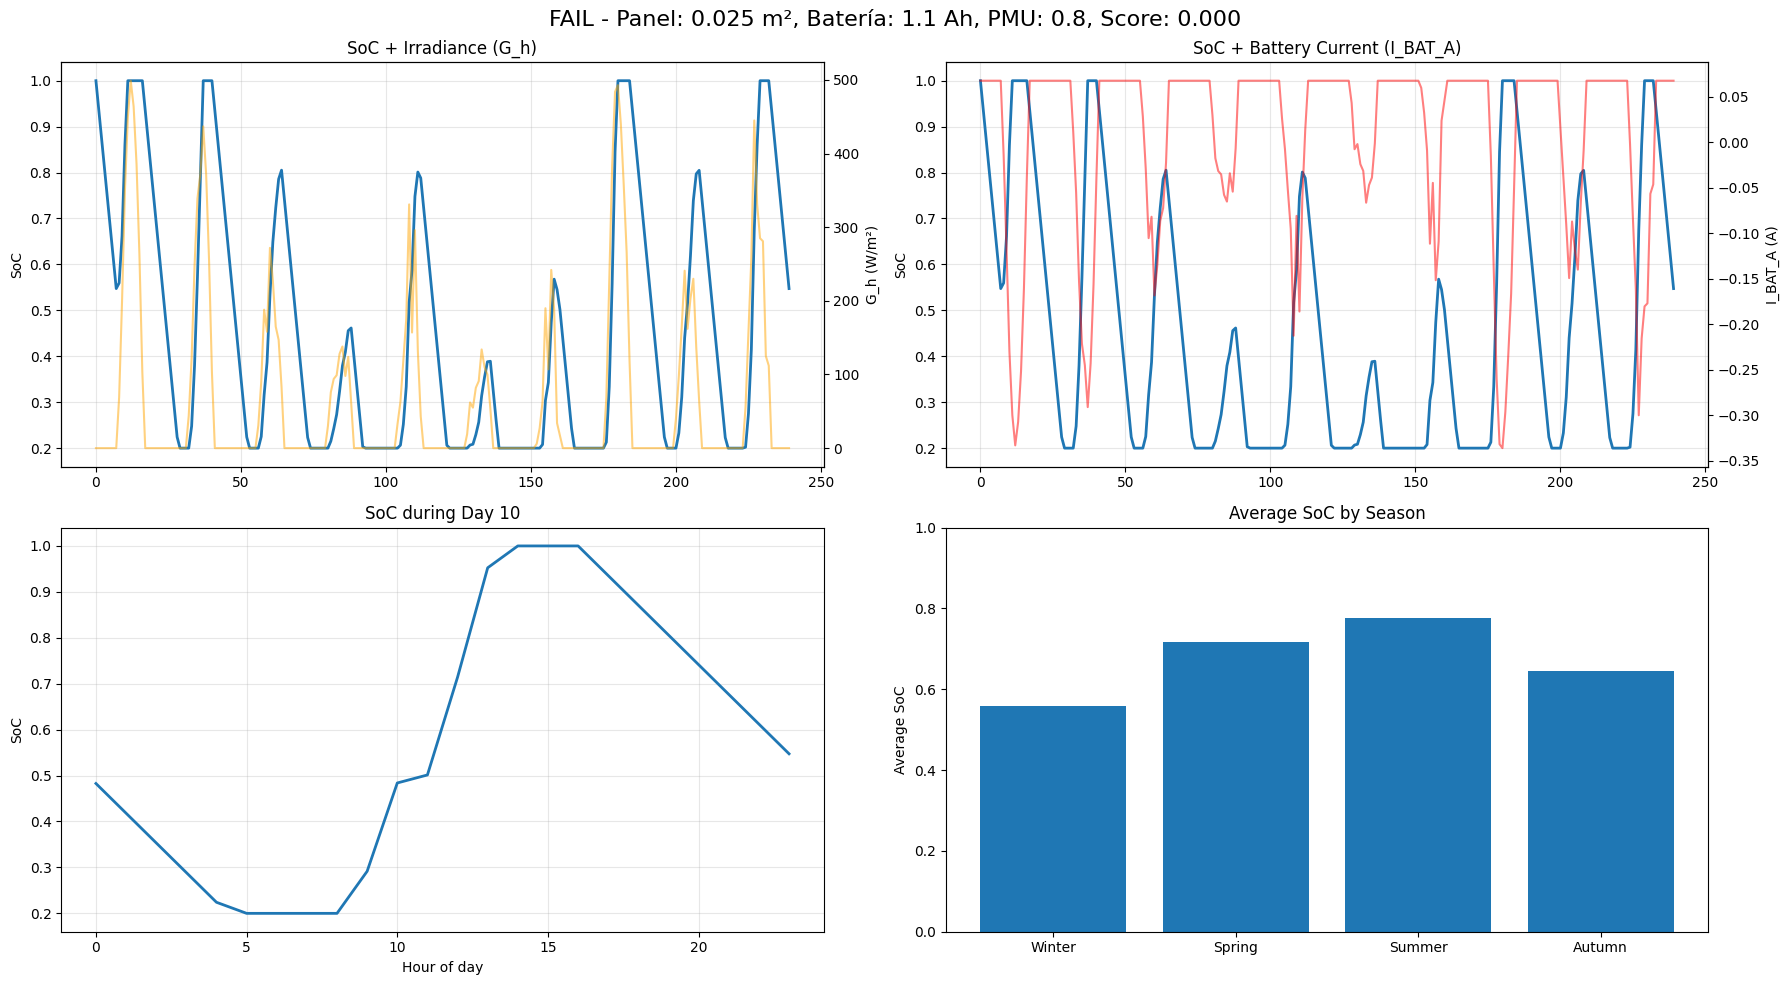

In [23]:
# === BEST SCORE ===
plot_full_soc_analysis(
    title_best,
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    title_mid,
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === BAD NON-ZERO SCORE ===
plot_full_soc_analysis(
    title_bad,
    df_soc, df_pv,
    cfg_bad["panel_area_m2"],
    cfg_bad["C_batt_Ah"],
    cfg_bad["eta_PMU"],
    hours=240,
    day_index=10
)

# === FAILURE CASE ===
plot_full_soc_analysis(
    title_fail,
    df_soc, df_pv,
    cfg_fail["panel_area_m2"],
    cfg_fail["C_batt_Ah"],
    cfg_fail["eta_PMU"],
    hours=240,
    day_index=10
)


## Pareto front

In [24]:
# ── Compute Pareto front ────────────────────────────────────────────────────
pareto_objectives = [
    ("C_batt_Ah",        -1),
    ("panel_area_m2",    -1),
    ("soc_full_fraction", -1),
]

front = simulator.pareto_front(summary, pareto_objectives)

print(f"{len(front)} configurations on the Pareto front (out of "
      f"{(summary['failure_hours'] == 0).sum()} viable ones)\n")

for i, row in front.iterrows():
    print(f"--- Config #{i} ---")
    print(f"  Panel area  : {row['panel_area_m2']*1e4:.1f} cm²  ({row['panel_area_m2']} m²)")
    print(f"  Battery     : {row['C_batt_Ah']} Ah")
    print(f"  η_PMU       : {row['eta_PMU']}")
    print(f"  SoC full    : {row['soc_full_fraction']*100:.1f}%")
    print(f"  Autonomy    : {row['autonomy_hours']} h")
    print(f"  Failures    : {int(row['failure_hours'])} h")
    print()


9 configurations on the Pareto front (out of 207 viable ones)

--- Config #0 ---
  Panel area  : 100000.0 cm²  (10.0 m²)
  Battery     : 1.1 Ah
  η_PMU       : 0.98
  SoC full    : 49.1%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #1 ---
  Panel area  : 400.0 cm²  (0.04 m²)
  Battery     : 1.2 Ah
  η_PMU       : 0.98
  SoC full    : 38.6%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #2 ---
  Panel area  : 385.0 cm²  (0.0385 m²)
  Battery     : 1.4 Ah
  η_PMU       : 0.95
  SoC full    : 37.6%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #3 ---
  Panel area  : 310.0 cm²  (0.031 m²)
  Battery     : 1.6 Ah
  η_PMU       : 0.98
  SoC full    : 36.2%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #4 ---
  Panel area  : 304.1 cm²  (0.030414 m²)
  Battery     : 1.8 Ah
  η_PMU       : 0.98
  SoC full    : 36.0%
  Autonomy    : 8760.0 h
  Failures    : 0 h

--- Config #5 ---
  Panel area  : 304.1 cm²  (0.030414 m²)
  Battery     : 2.0 Ah
  η_PMU   

# Compute score from Pareto front¶
Pareto front¶

In [25]:
score_objectives = [
    ("surplus_Ah",        -0.33),
    ("eta_PMU",           -0.33),
    ("soc_std",           -0.33),
]

score = simulator.compute_score(front, score_objectives)

# columnas a mostrar
cols = [
    "panel_area_m2",
    "C_batt_Ah",
    "soc_full_fraction",
    "eta_PMU",
    "soc_mean",
    "soc_std",
    "surplus_Ah",
    "deficit_Ah",
    "hours_soc_full",
    "score",
]

tabla = score[cols]

# función para formatear valores
def fmt(v):
    if isinstance(v, float):
        return f"{v:.5f}"
    return str(v)

# calcular ancho máximo de cada columna
widths = []
for col in tabla.columns:
    max_data = tabla[col].map(fmt).map(len).max()
    widths.append(max(max_data, len(col)))

# encabezado
header = "  ".join(col.ljust(w) for col, w in zip(tabla.columns, widths))
print(header)

# línea separadora
print("-" * len(header))

# filas
for _, row in tabla.iterrows():
    line = "  ".join(fmt(v).ljust(w) for v, w in zip(row, widths))
    print(line)


panel_area_m2  C_batt_Ah  soc_full_fraction  eta_PMU  soc_mean  soc_std  surplus_Ah  deficit_Ah    hours_soc_full  score  
--------------------------------------------------------------------------------------------------------------------------
0.02500        2.50000    0.33767            0.98000  0.88875   0.11344  254.66150   1714.37542    2958.00000      0.59700
0.03850        2.30000    0.34897            0.85000  0.86594   0.13662  291.12804   2048.26276    3057.00000      0.59326
0.01600        10.20000   0.23733            0.90000  0.92705   0.11929  283.24682   847.10738     2079.00000      0.57393
0.03041        2.00000    0.35194            0.95000  0.86290   0.14055  261.36467   1996.84413    3083.00000      0.54602
0.03041        1.80000    0.35982            0.98000  0.85503   0.14999  253.14265   2131.70949    3152.00000      0.50287
0.03100        1.60000    0.36187            0.98000  0.83767   0.16834  253.00891   2176.91029    3170.00000      0.45103
0.03850        1

# Visualize SOC through year

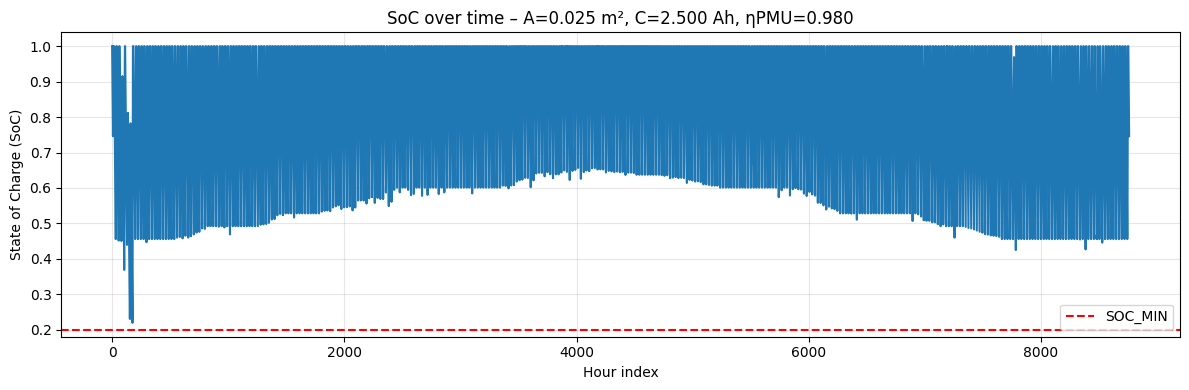

In [26]:
cfg = score.iloc[0]   # primera fila del DataFrame

plt.figure(figsize=(12, 4))
plt.plot(config_soc['hour_index'], config_soc['SoC'])

plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')

plt.xlabel('Hour index')
plt.ylabel('State of Charge (SoC)')
plt.title(
    f"SoC over time – A={cfg['panel_area_m2']:.3f} m², "
    f"C={cfg['C_batt_Ah']:.3f} Ah, ηPMU={cfg['eta_PMU']:.3f}"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("soc_plot.png", dpi=300)   # <-- guarda la imagen
plt.show()